# LLH Parameter Impact on Return Distributions —  Stylized Facts Experiments

The LLH (improved Stein–Stein) model extends that of Black–Scholes with stochastic volatility:

$$
\frac{dS_t}{S_t} = r\,dt + \sigma_t\,dW^1_t, \qquad
d\sigma_t = \kappa(\theta_t - \sigma_t)\,dt + \nu\,dW^2, \qquad
d\theta_t = \lambda\,dt + \eta\,dB_t
$$

where $\text{Corr}(W^1, W^2) = \rho$ and $B$ is an independent GBM driver.

We vary $(\kappa, \nu, \rho, \lambda, \eta, \sigma_0, \theta_0)$ and measure their impact on log-return distributions, connecting each parameter to well-known **stylized facts** of stock returns.

In [23]:
import sys, os

from overrides import overrides
sys.path.insert(0, os.path.join(os.pardir, 'src'))

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import priceModels as pm

%matplotlib inline
plt.rcParams.update({
    'figure.figsize': (10, 6),
    'font.size': 12,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

# --------------- Base parameters ---------------
base = dict(r=0.01, kappa=5.0, nu=0.2, sigma0=0.15, theta0=0.18,
            lam=0.9, eta=0.01, rho=-0.2, seed=123)
S0, T, n_steps_mc, n_paths = 100.0, 2.0, 252, 25_000

# --------------- Helpers ---------------
def simulate(overrides=None):
    """Run simulation with optional parameter overrides. Returns S, sigma_hat arrays."""
    params = dict(base)
    if isinstance(overrides, dict):
         params.update(overrides)
    model = pm.ImprovedSteinStein(**params)
    res = model.simulate_prices(S0=S0, T=T, n_steps_mc=n_steps_mc, n_paths=n_paths)
    return res['S'], res['sigma_hat']

def log_returns(S):
    """Compute log-returns from price array. Shape: (n_paths, n_steps_mc)."""
    return np.diff(np.log(S), axis=1)

def terminal_log_return(S):
    """log(S_T / S_0) for each path."""
    return np.log(S[:, -1] / S[:, 0])

## Experiment 1: Leverage Effect (vary correlation of risk drivers $\rho$)

**Stylized fact**: Negative correlation between returns and volatility changes ("leverage effect") produces negatively skewed return distributions.

**Sweep**: $\rho \in \{-0.8, -0.5, -0.2, 0.0, 0.2, 0.5, 0.8\}$

**Expected**: More negative $\rho$ → more negative skewness, visible asymmetry in return distribution.

In [32]:
rho_vals = [-0.8, -0.5, -0.2, 0.0, 0.2, 0.5, 0.8]

# --- Simulate and collect metrics ---
rho_results = {}
for rho in rho_vals:
    S, sigma_hat = simulate({'rho': rho})
    lr = log_returns(S)
    tlr = terminal_log_return(S)
    rho_results[rho] = {
        'S': S, 'sigma_hat': sigma_hat,
        'lr': lr, 'tlr': tlr,
        'skew': stats.skew(tlr),
        'kurt': stats.kurtosis(tlr),  # excess kurtosis
    }

# --- Print summary ---
print(f"{'rho':>6s}  {'skewness':>10s}  {'ex. kurtosis':>15s}")
print("-" * 34)
for rho in rho_vals:
    r = rho_results[rho]
    print(f"{rho:>6.1f}  {r['skew']:>10.4f}  {r['kurt']:>15.4f}")

   rho    skewness     ex. kurtosis
----------------------------------
  -0.8     -0.1628           0.0709
  -0.5     -0.1211           0.0587
  -0.2     -0.0777           0.0504
   0.0     -0.0479           0.0472
   0.2     -0.0174           0.0459
   0.5      0.0299           0.0480
   0.8      0.0790           0.0550


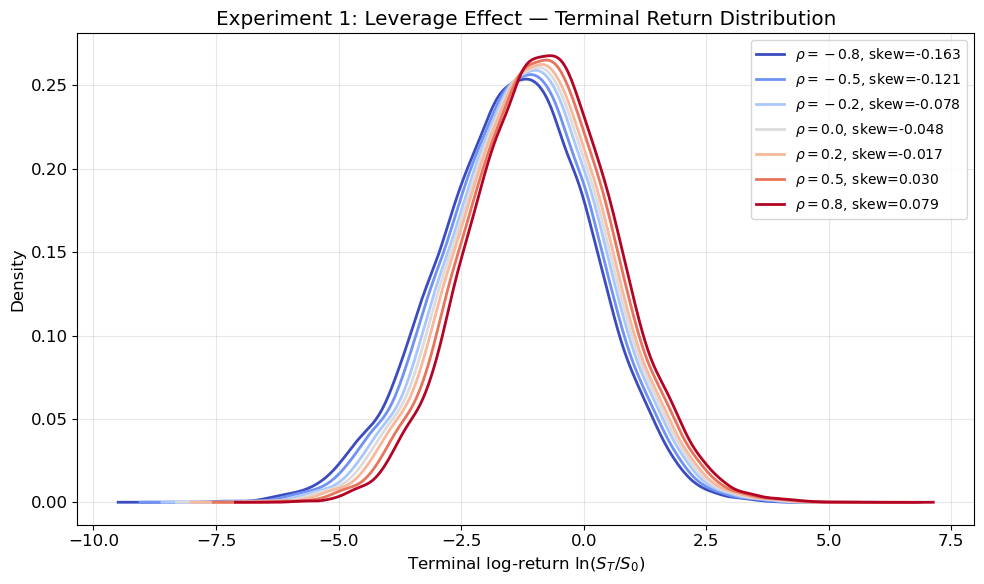

In [ ]:
# --- Figure 1a: Density plots of terminal log-returns ---

from scipy.stats import gaussian_kde                                                                                              
                  
fig, ax = plt.subplots(figsize=(10, 6))                                                                                           
colors = plt.cm.coolwarm(np.linspace(0, 1, len(rho_vals)))
for rho, c in zip(rho_vals, colors):                                                                                              
    tlr = rho_results[rho]['tlr']
    kde = gaussian_kde(tlr)                                                                                                       
    x = np.linspace(tlr.min(), tlr.max(), 500)
    ax.plot(x, kde(x), color=c, lw=2,                                                                                             
            label=rf'$\rho={rho:.1f}$, skew={rho_results[rho]["skew"]:.3f}')                                                      
ax.set_xlabel(r'Terminal log-return $\ln(S_T/S_0)$')
ax.set_ylabel('Density')                                                                                                          
ax.set_title('Experiment 1: Leverage Effect — Terminal Return Distribution')
ax.legend(fontsize=10)                                                                                                            
plt.tight_layout()                                                                                                                
plt.show()

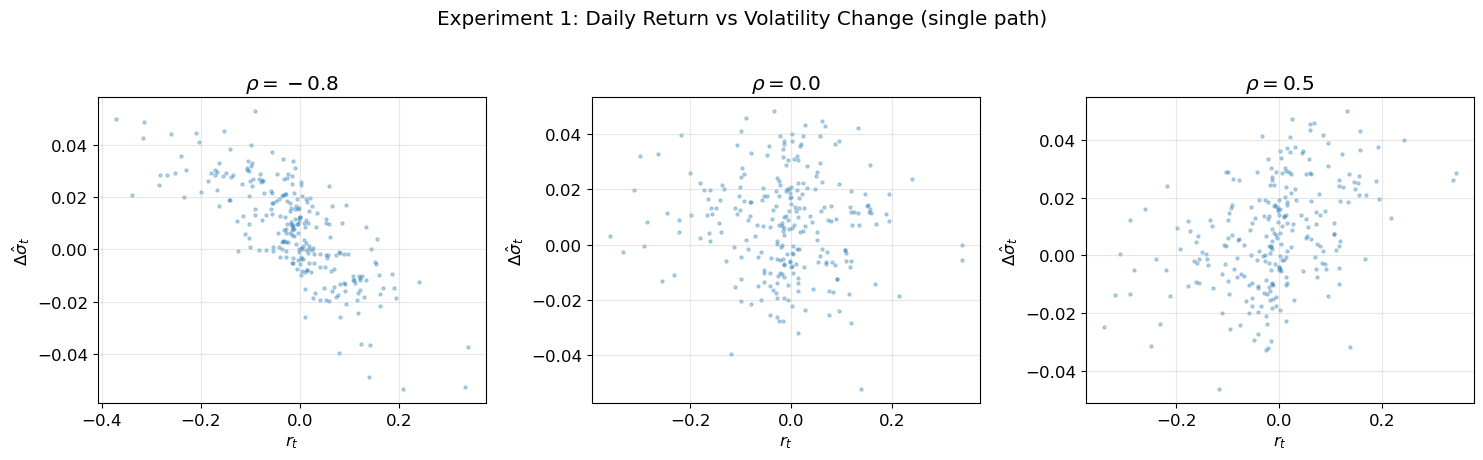

In [31]:
# --- Figure 1b: Scatter — daily return vs Δσ for one path (extreme ρ values) ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
scatter_rhos = [-0.8, 0.0, 0.5]
for ax, rho in zip(axes, scatter_rhos):
    lr = rho_results[rho]['lr']
    sh = rho_results[rho]['sigma_hat']
    # Δσ_t = sigma_hat[:, t] - sigma_hat[:, t-1]; align with lr[:, 1:]
    dsig = np.diff(sh, axis=1)
    # subsample: use first path
    path_idx = 0
    ax.scatter(lr[path_idx, 1:], dsig[path_idx], alpha=0.3, s=5, rasterized=True)
    ax.set_xlabel(r'$r_t$')
    ax.set_ylabel(r'$\Delta\hat{\sigma}_t$')
    ax.set_title(rf'$\rho = {rho:.1f}$')
fig.suptitle('Experiment 1: Daily Return vs Volatility Change (single path)', y=1.02)
plt.tight_layout()
plt.show()

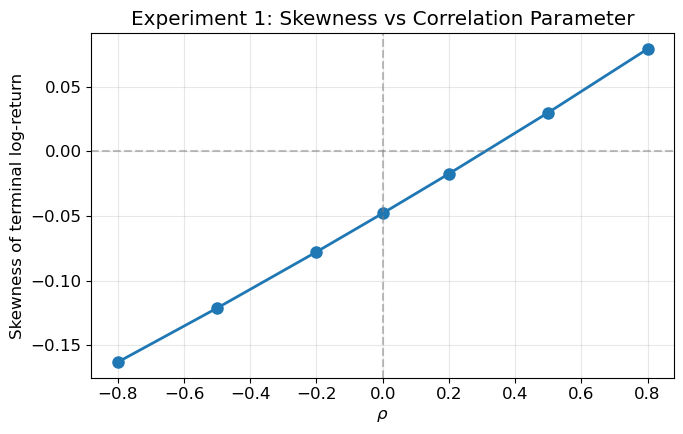

In [38]:
# --- Figure 1c: Skewness vs ρ ---
fig, ax = plt.subplots(figsize=(7, 4.5))
skews = [rho_results[rho]['skew'] for rho in rho_vals]
ax.plot(rho_vals, skews, 'o-', markersize=8, linewidth=2)
ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.axvline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel(r'$\rho$')
ax.set_ylabel('Skewness of terminal log-return')
ax.set_title('Experiment 1: Skewness vs Correlation Parameter')
plt.tight_layout()
plt.show()

## Experiment 2: Heavy Tails (vary the vol-of-vol $\nu$)

**Stylized fact**: Higher volatility-of-volatility produces heavier tails (excess kurtosis) in the return distribution, deviating from normality.

**Sweep**: $\nu \in \{0.01, 0.05, 0.1, 0.2, 0.4\}$

**Expected**: Higher $\nu$ → fatter tails (higher kurtosis), deviation from normality visible in QQ tails.

In [49]:
nu_vals = [0.01, 0.1, 0.5, 0.9]

nu_results = {}
for nu in nu_vals:
    S, sigma_hat = simulate({'nu': nu})
    tlr = terminal_log_return(S)
    nu_results[nu] = {
        'S': S,
        'tlr': tlr,
        'skew': stats.skew(tlr),
        'kurt': stats.kurtosis(tlr),  # excess kurtosis
    }

print(f"{'nu':>6s}  {'skewness':>10s}  {'ex. kurtosis':>12s}")
print("-" * 34)
for nu in nu_vals:
    r = nu_results[nu]
    print(f"{nu:>6.2f}  {r['skew']:>10.4f}  {r['kurt']:>12.4f}")

    nu    skewness  ex. kurtosis
----------------------------------
  0.01     -0.0414        0.0362
  0.10     -0.0573        0.0408
  0.50     -0.1542        0.1090
  0.90     -0.2817        0.2539


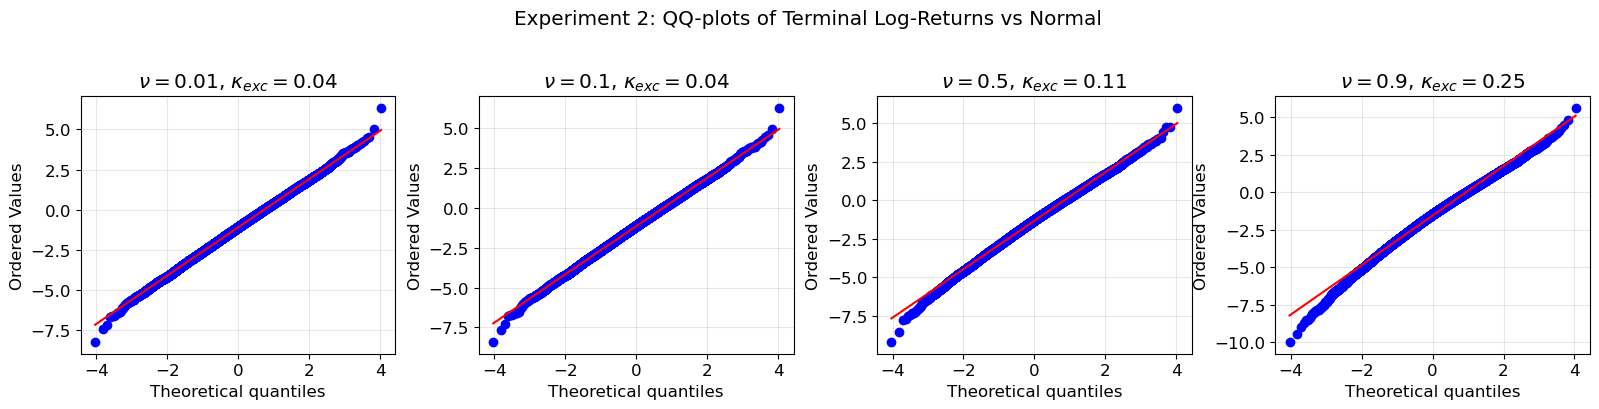

In [50]:
# --- Figure 2a: QQ-plots vs normal ---
fig, axes = plt.subplots(1, len(nu_vals), figsize=(4 * len(nu_vals), 4))
for ax, nu in zip(axes, nu_vals):
    sample = nu_results[nu]['tlr']
    stats.probplot(sample, dist='norm', plot=ax)
    ax.set_title(rf'$\nu={nu}$, $\kappa_{{exc}}={nu_results[nu]["kurt"]:.2f}$')
fig.suptitle('Experiment 2: QQ-plots of Terminal Log-Returns vs Normal', y=1.02)
plt.tight_layout()
plt.show()

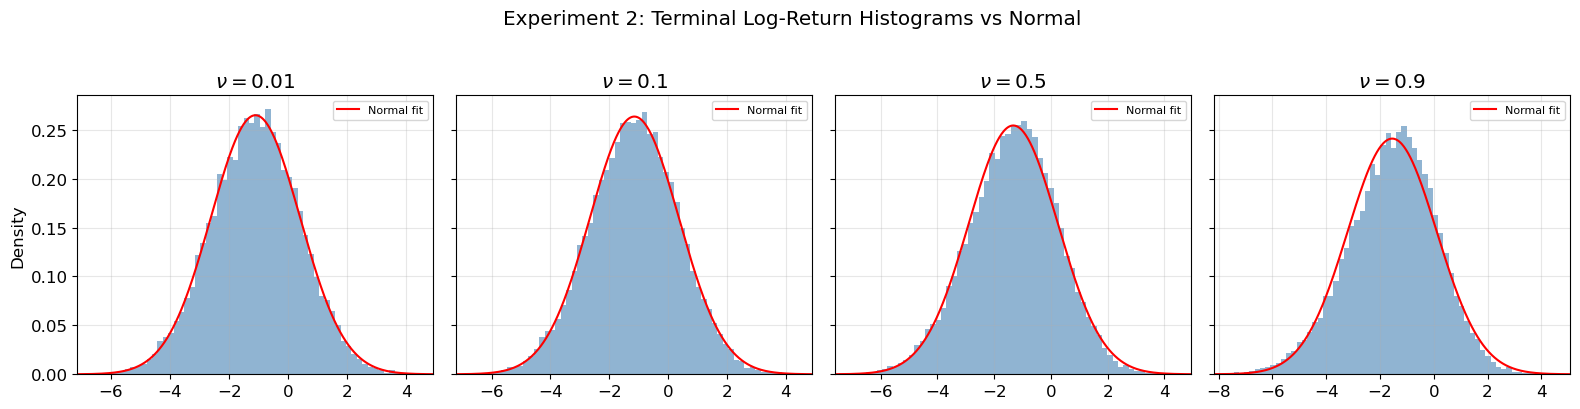

In [51]:
# --- Figure 2b: Histogram with normal density overlay ---
from scipy.stats import gaussian_kde as _kde

fig, axes = plt.subplots(1, len(nu_vals), figsize=(4 * len(nu_vals), 4), sharey=True)
for ax, nu in zip(axes, nu_vals):
    sample = nu_results[nu]['tlr']
    mu, sig = sample.mean(), sample.std()
    ax.hist(sample, bins=80, density=True, alpha=0.6, color='steelblue')
    x = np.linspace(mu - 4 * sig, mu + 4 * sig, 500)
    ax.plot(x, stats.norm.pdf(x, mu, sig), 'r-', linewidth=1.5, label='Normal fit')
    ax.set_title(rf'$\nu={nu}$')
    ax.set_xlim(mu - 4 * sig, mu + 4 * sig)
    ax.legend(fontsize=8)
axes[0].set_ylabel('Density')
fig.suptitle('Experiment 2: Terminal Log-Return Histograms vs Normal', y=1.02)
plt.tight_layout()
plt.show()

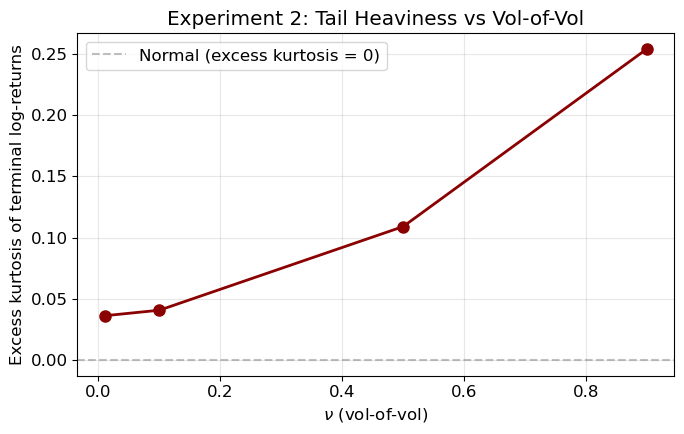

In [52]:
# --- Figure 2c: Excess kurtosis vs ν ---
fig, ax = plt.subplots(figsize=(7, 4.5))
kurts = [nu_results[nu]['kurt'] for nu in nu_vals]
ax.plot(nu_vals, kurts, 'o-', markersize=8, linewidth=2, color='darkred')
ax.axhline(0, color='gray', linestyle='--', alpha=0.5, label='Normal (excess kurtosis = 0)')
ax.set_xlabel(r'$\nu$ (vol-of-vol)')
ax.set_ylabel('Excess kurtosis of terminal log-returns')
ax.set_title('Experiment 2: Tail Heaviness vs Vol-of-Vol')
ax.legend()
plt.tight_layout()
plt.show()

## Experiment 3: Volatility Clustering (vary mean-reversion speed $\kappa$)

**Stylized fact**: Absolute (or squared) returns exhibit significant positive autocorrelation that decays slowly — "volatility clustering." The mean-reversion speed $\kappa$ controls how persistent these vol regimes are.

**Sweep**: $\kappa \in \{0.5, 1, 2, 5, 10, 20\}$

**Expected**: Small $\kappa$ → slow ACF decay of $|r_t|$ (persistent clustering); large $\kappa$ → fast decay. Raw return ACF stays near zero (efficient market). Theoretical half-life: $\ln(2)/\kappa$.

In [57]:
from statsmodels.tsa.stattools import acf as _acf

kappa_vals = [0.5, 1.0, 2.0, 5.0, 10.0, 20.0]
max_lag = 60

def sample_acf(x, max_lag):
    """ACF up to max_lag, averaged over paths if 2-D."""
    if x.ndim == 2:
        n_sample = min(x.shape[0], 2000)
        idx = np.random.default_rng(42).choice(x.shape[0], n_sample, replace=False)
        return np.mean([_acf(x[i], nlags=max_lag, fft=True) for i in idx], axis=0)
    return _acf(x, nlags=max_lag, fft=True)

kappa_results = {}
for kappa in kappa_vals:
    S, _ = simulate({'kappa': kappa})
    lr = log_returns(S)
    abs_lr = np.abs(lr)
    acf_abs = sample_acf(abs_lr, max_lag)
    acf_raw = sample_acf(lr, max_lag)
    kappa_results[kappa] = {
        'acf_abs': acf_abs,
        'acf_raw': acf_raw,
        'half_life': np.log(2) / kappa,
    }

print("Simulations complete.")

Simulations complete.


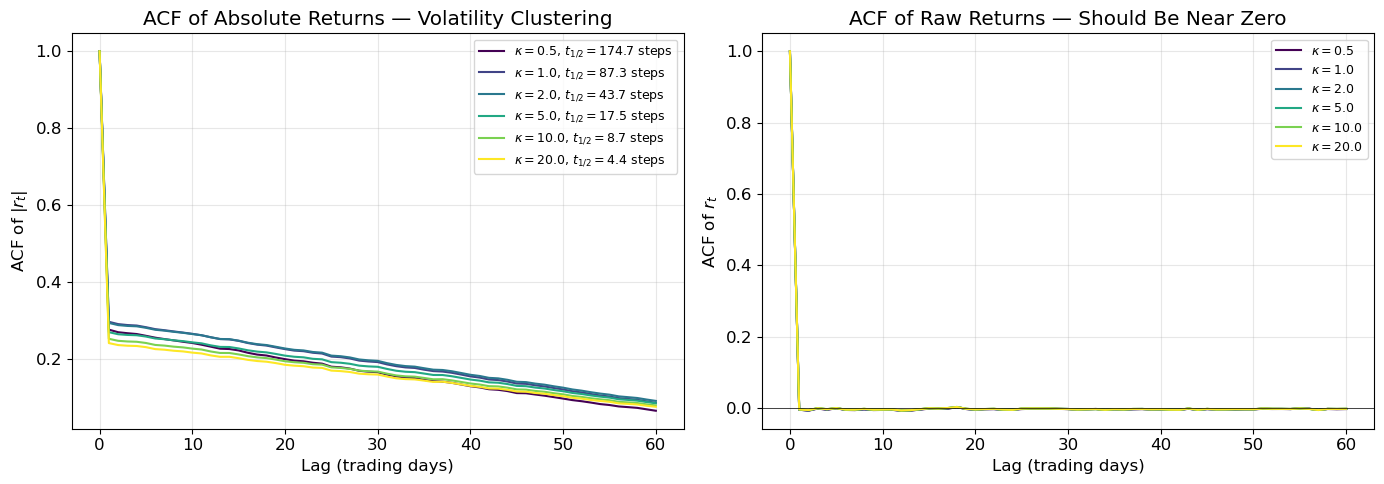

In [58]:
# --- Figure 3a: ACF of |r_t| for different κ ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
lags = np.arange(max_lag + 1)
colors = plt.cm.viridis(np.linspace(0, 1, len(kappa_vals)))

ax = axes[0]
for kappa, c in zip(kappa_vals, colors):
    r = kappa_results[kappa]
    hl = r['half_life']
    # Convert half-life from continuous time to steps
    dt = T / n_steps_mc
    hl_steps = hl / dt
    ax.plot(lags, r['acf_abs'], color=c, linewidth=1.5,
            label=rf'$\kappa={kappa}$, $t_{{1/2}}={hl_steps:.1f}$ steps')
ax.set_xlabel('Lag (trading days)')
ax.set_ylabel(r'ACF of $|r_t|$')
ax.set_title(r'ACF of Absolute Returns — Volatility Clustering')
ax.legend(fontsize=9)

ax = axes[1]
for kappa, c in zip(kappa_vals, colors):
    ax.plot(lags, kappa_results[kappa]['acf_raw'], color=c, linewidth=1.5,
            label=rf'$\kappa={kappa}$')
ax.axhline(0, color='black', linewidth=0.5)
ax.set_xlabel('Lag (trading days)')
ax.set_ylabel(r'ACF of $r_t$')
ax.set_title('ACF of Raw Returns — Should Be Near Zero')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

## Experiment 4: Stochastic Long-Run Mean (vary $\lambda$, $\eta$)

**Stylized fact**: Financial time series exhibit "long memory" in volatility — autocorrelations in $|r_t|$ that persist at very long lags. The LLH extension adds a stochastic long-run mean $\theta_t$ whose drift $\lambda$ and diffusion $\eta$ inject low-frequency volatility variation.

**Comparison grid**:
- SS limit: $\lambda=\eta=0$
- Drift only: $\lambda=0.9, \eta=0$
- Diffusion only: $\lambda=0, \eta=0.5$
- Full LLH: $\lambda=0.9, \eta=0.5$

**Expected**: Nonzero $\lambda/\eta$ → slower ACF decay at long lags. Rolling vol shows "regime-like" shifts absent in the SS limit.

In [76]:
exp4_configs = {
    'SS limit (λ=η=0)':          {'lam': 0.0, 'eta': 0.0},
    'Drift only (λ=0.9, η=0)':   {'lam': 0.9, 'eta': 0.0},
    'Diffusion only (λ=0, η=0.05)': {'lam': 0.0, 'eta': 0.05},
    'Full LLH (λ=0.9, η=0.05)':   {'lam': 0.9, 'eta': 0.05},
}

max_lag_long = 200

exp4_results = {}
for name, overrides in exp4_configs.items():
    S, sigma_hat = simulate(overrides)
    lr = log_returns(S)
    abs_lr = np.abs(lr)
    acf_abs = sample_acf(abs_lr, max_lag_long)
    exp4_results[name] = {
        'S': S, 'sigma_hat': sigma_hat,
        'lr': lr, 'acf_abs': acf_abs,
    }

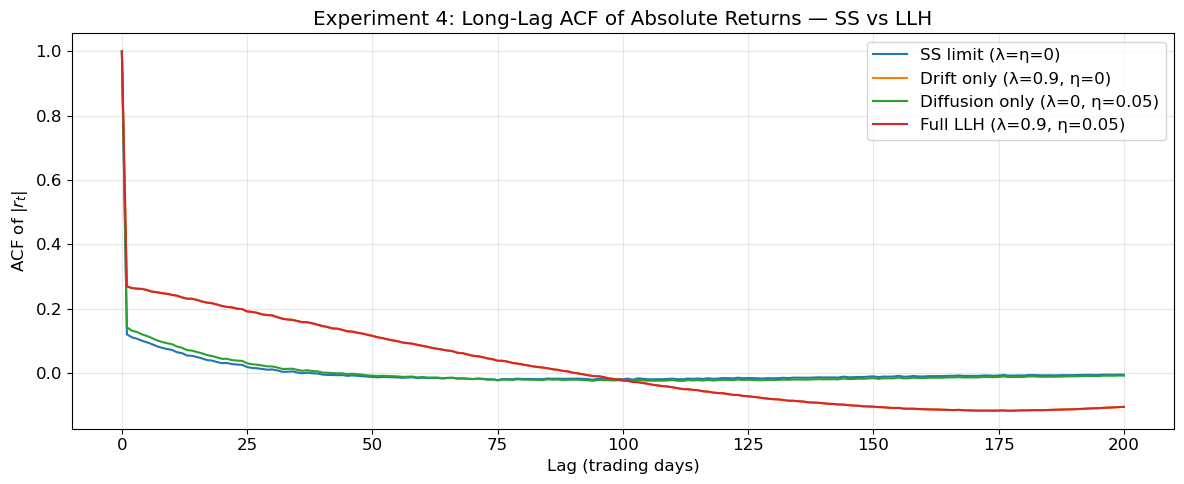

In [77]:
# --- Figure 4a: ACF of |r_t| at long lags ---
fig, ax = plt.subplots(figsize=(12, 5))
lags_long = np.arange(max_lag_long + 1)
colors4 = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
for (name, r), c in zip(exp4_results.items(), colors4):
    ax.plot(lags_long, r['acf_abs'], color=c, linewidth=1.5, label=name)
ax.set_xlabel('Lag (trading days)')
ax.set_ylabel(r'ACF of $|r_t|$')
ax.set_title('Experiment 4: Long-Lag ACF of Absolute Returns — SS vs LLH')
ax.legend()
plt.tight_layout()
plt.show()

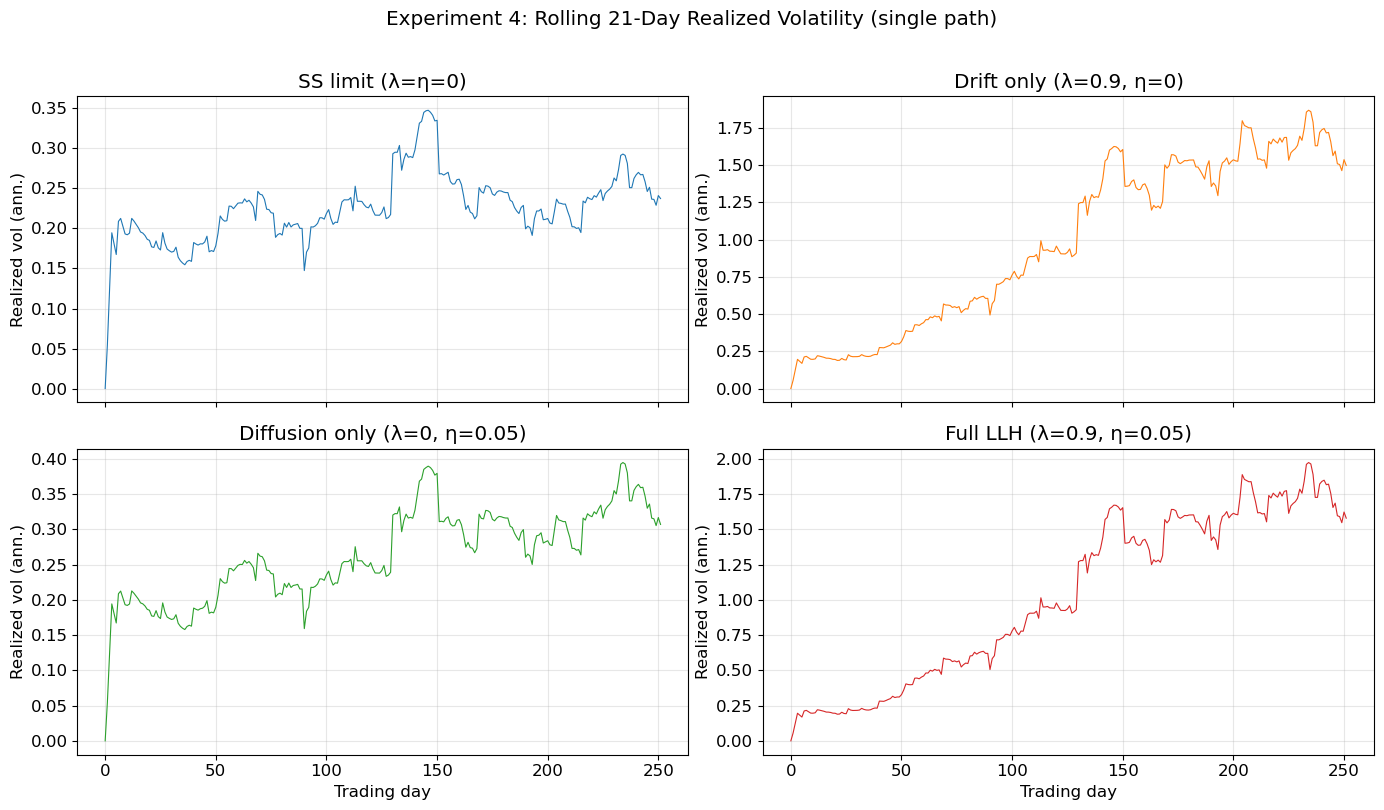

In [78]:
# --- Figure 4b: Rolling realized volatility (21-day window) for a single path ---
window = 21
path_idx = 0

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
for ax, (name, r), c in zip(axes.ravel(), exp4_results.items(), colors4):
    lr_path = r['lr'][path_idx]
    # Rolling realized vol = std of returns in a sliding window
    rv = np.array([lr_path[max(0,i-window):i].std() for i in range(1, len(lr_path)+1)])
    # Annualize (multiply by sqrt of steps per year)
    steps_per_year = n_steps_mc / T
    rv_ann = rv * np.sqrt(steps_per_year)
    ax.plot(rv_ann, color=c, linewidth=0.8)
    ax.set_title(name)
    ax.set_ylabel('Realized vol (ann.)')
axes[-1, 0].set_xlabel('Trading day')
axes[-1, 1].set_xlabel('Trading day')
fig.suptitle(f'Experiment 4: Rolling {window}-Day Realized Volatility (single path)', y=1.01)
plt.tight_layout()
plt.show()

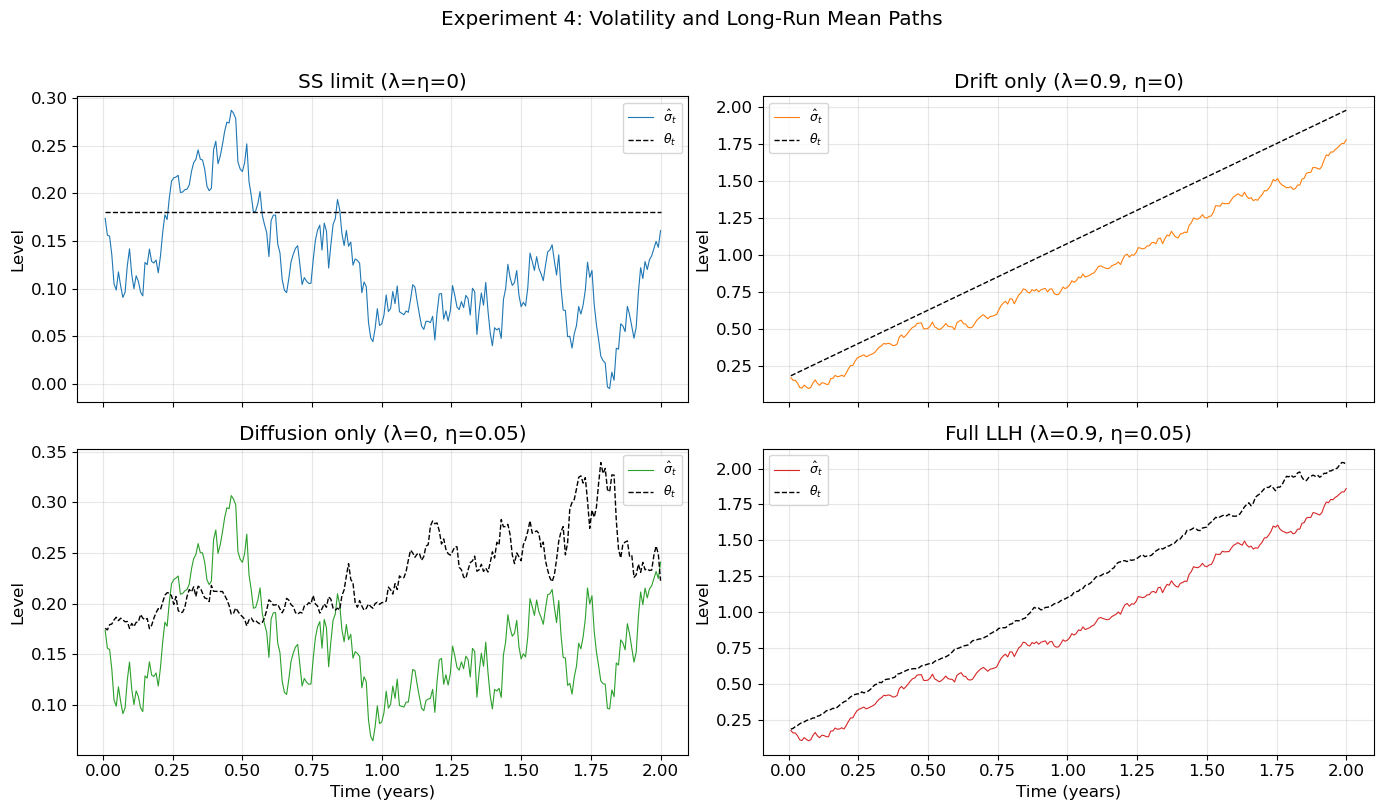

In [79]:
# --- Figure 4c: Time series of σ_t and θ_t for one representative path ---
# σ_hat is directly available; θ_t needs to be reconstructed from the model formula
# θ_t = θ_0 + λt + η(B_t - 1), but B is not stored. We can approximate θ_t from
# the sigma_hat formula. Instead, let's re-simulate to get B and compute θ_t directly.

path_idx = 0
dt = T / n_steps_mc
t_grid = np.arange(1, n_steps_mc + 1) * dt

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
for ax, (name, overrides), c in zip(axes.ravel(), exp4_configs.items(), colors4):
    params = {**base, **overrides}
    model = pm.ImprovedSteinStein(**params)
    res = model.simulate_prices(S0=S0, T=T, n_steps_mc=n_steps_mc, n_paths=min(n_paths, 1000))
    sigma_path = res['sigma_hat'][path_idx]
    # Reconstruct θ_t = θ_0 + λt + η(B_t - 1)
    B_path = res['B'][path_idx]
    theta_path = params['theta0'] + params['lam'] * t_grid + params['eta'] * (B_path - 1.0)
    ax.plot(t_grid, sigma_path, color=c, linewidth=0.8, label=r'$\hat{\sigma}_t$')
    ax.plot(t_grid, theta_path, color='black', linewidth=1.0, linestyle='--', label=r'$\theta_t$')
    ax.set_title(name)
    ax.set_ylabel('Level')
    ax.legend(fontsize=9)
axes[-1, 0].set_xlabel('Time (years)')
axes[-1, 1].set_xlabel('Time (years)')
fig.suptitle('Experiment 4: Volatility and Long-Run Mean Paths', y=1.01)
plt.tight_layout()
plt.show()

## Experiment 5:BS vs SS vs LLH

Progressive enrichment from Black–Scholes (constant vol) to Stein–Stein (stochastic vol, fixed long-run mean) to the full LLH model (stochastic long-run mean). Each step adds stylized facts that better match empirical observations.

| Model | Parameters |
|-------|-----------|
| **BS** | $\kappa=\nu=\lambda=\eta=\rho=0$ (constant $\sigma=\sigma_0$) |
| **SS** | $\lambda=\eta=0$, $\rho=-0.2$ (mean-reverting stochastic vol) |
| **LLH** | All parameters active (stochastic vol + stochastic long-run mean) |

In [80]:
exp5_configs = {
    'BS':  {'kappa': 0.0, 'nu': 0.0, 'lam': 0.0, 'eta': 0.0, 'rho': 0.0},
    'SS':  {'lam': 0.0, 'eta': 0.0, 'rho': -0.2},
    'LLH': {},  # use all base params
}

max_lag_5 = 100

exp5_results = {}
for name, overrides in exp5_configs.items():
    S, sigma_hat = simulate(overrides)
    lr = log_returns(S)
    tlr = terminal_log_return(S)
    abs_lr = np.abs(lr)
    acf_abs = sample_acf(abs_lr, max_lag_5)
    exp5_results[name] = {
        'S': S, 'lr': lr, 'tlr': tlr,
        'mean': tlr.mean(),
        'std': tlr.std(),
        'skew': stats.skew(tlr),
        'kurt': stats.kurtosis(tlr),
        'acf_abs': acf_abs,
    }

# --- Summary statistics table ---
print(f"{'Model':<6s}  {'Mean':>10s}  {'Std':>10s}  {'Skewness':>10s}  {'Ex. Kurt.':>10s}")
print("-" * 52)
for name in exp5_configs:
    r = exp5_results[name]
    print(f"{name:<6s}  {r['mean']:>10.6f}  {r['std']:>10.6f}  {r['skew']:>10.4f}  {r['kurt']:>10.4f}")

Model         Mean         Std    Skewness   Ex. Kurt.
----------------------------------------------------
BS       -0.003474    0.211724     -0.0215      0.0225
SS       -0.093600    0.268143     -0.2190      0.3094
LLH      -1.187285    1.524559     -0.0777      0.0504


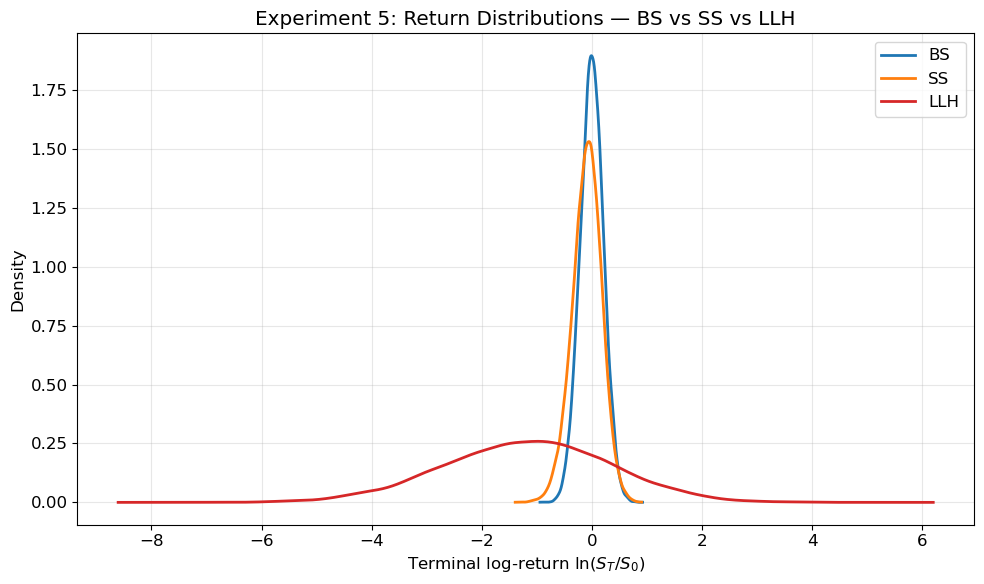

In [81]:
# --- Figure 5a: Overlaid return densities ---
from scipy.stats import gaussian_kde as _kde5

fig, ax = plt.subplots(figsize=(10, 6))
colors5 = {'BS': '#1f77b4', 'SS': '#ff7f0e', 'LLH': '#d62728'}
for name in exp5_configs:
    r = exp5_results[name]
    tlr = r['tlr']
    kde = _kde5(tlr)
    x = np.linspace(tlr.min(), tlr.max(), 500)
    ax.plot(x, kde(x), color=colors5[name], lw=2, label=name)
ax.set_xlabel(r'Terminal log-return $\ln(S_T/S_0)$')
ax.set_ylabel('Density')
ax.set_title('Experiment 5: Return Distributions — BS vs SS vs LLH')
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

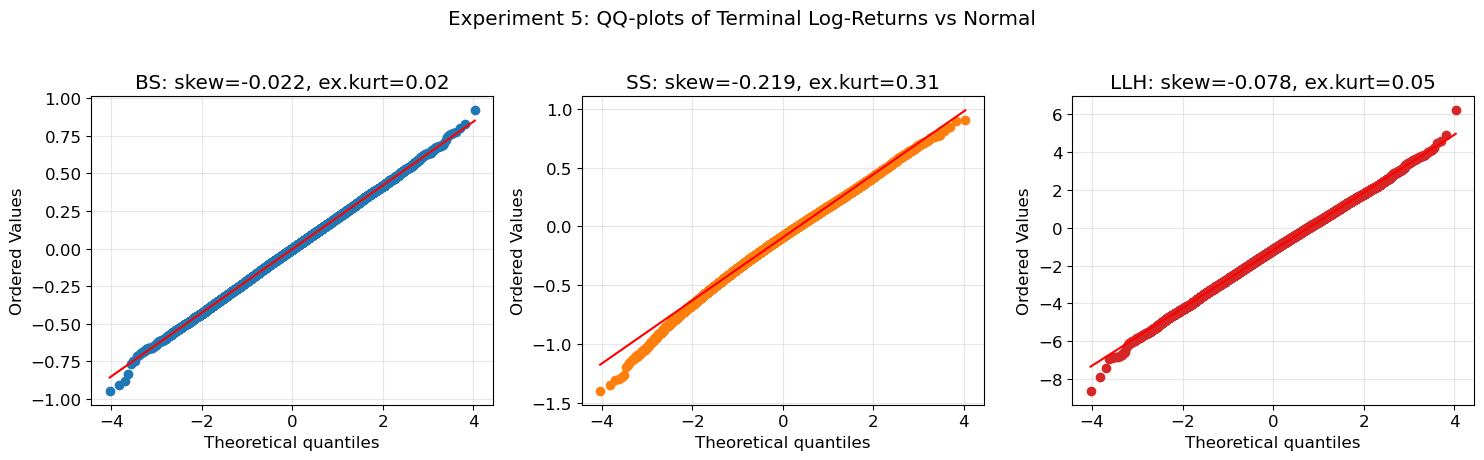

In [82]:
# --- Figure 5b: QQ-plots (one per model, 3-panel) ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (name, c) in zip(axes, colors5.items()):
    r = exp5_results[name]
    stats.probplot(r['tlr'], dist='norm', plot=ax)
    ax.set_title(f'{name}: skew={r["skew"]:.3f}, ex.kurt={r["kurt"]:.2f}')
    ax.get_lines()[0].set_color(c)
fig.suptitle('Experiment 5: QQ-plots of Terminal Log-Returns vs Normal', y=1.02)
plt.tight_layout()
plt.show()

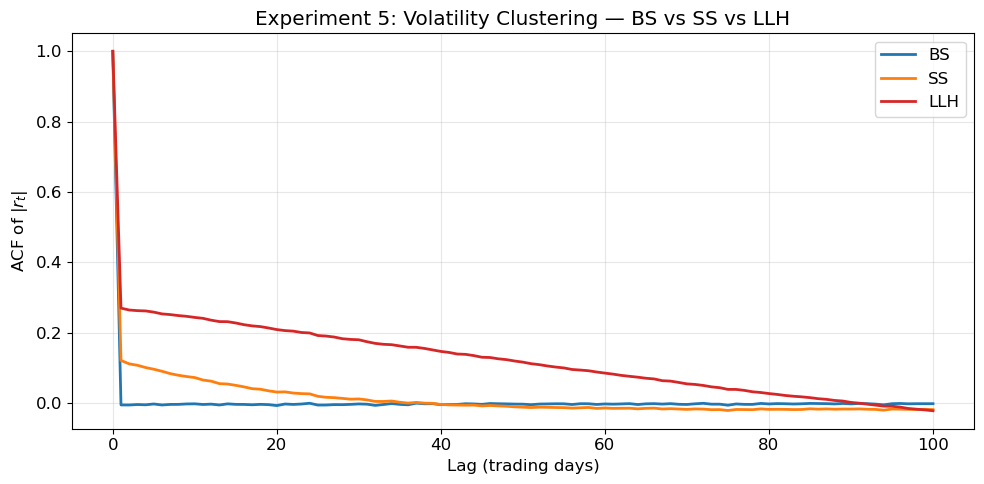

In [83]:
# --- Figure 5c: ACF of |r_t| (3 curves overlaid) ---
fig, ax = plt.subplots(figsize=(10, 5))
lags5 = np.arange(max_lag_5 + 1)
for name, c in colors5.items():
    ax.plot(lags5, exp5_results[name]['acf_abs'], color=c, linewidth=2, label=name)
ax.set_xlabel('Lag (trading days)')
ax.set_ylabel(r'ACF of $|r_t|$')
ax.set_title('Experiment 5: Volatility Clustering — BS vs SS vs LLH')
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

## Verification Checklist

1. **BS-limit sanity** (Exp 5): BS row should show skewness ≈ 0, excess kurtosis ≈ 0, zero ACF in |r_t|
2. **ρ=0 → zero skewness** (Exp 1): confirmed in the skewness table
3. **ν→0 → kurtosis→0** (Exp 2): smallest ν should show near-zero excess kurtosis
4. **Large κ → rapid ACF decay** (Exp 3): half-life ln(2)/κ matches observed ACF decay
5. **SS vs LLH diverge at long lags** (Exp 4): LLH extension shows slower ACF decay at long lags